## Download model

In [78]:
# !git clone https://github.com/facebookresearch/segment-anything.git

In [104]:
import os 
HOME = os.getcwd()
print(HOME)

d:\deep learning\Deep-learning\SAM


In [ ]:
# os.makedirs(os.path.join(HOME, "weights"), exist_ok=True)

In [105]:
%cd {HOME}/weights

d:\deep learning\Deep-learning\SAM\weights


In [ ]:
# !curl -L https://dl.fbaipublicfiles.com/segment-anything/sam_vit_b_01ec64.pth -o sam_vit_b_01ec64.pth


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   111    0   111    0     0    146      0 --:--:-- --:--:-- --:--:--   146


## Import lib.

In [106]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 
import math

In [107]:
import torch 
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda:0


In [109]:
import os 
%cd {HOME}

MODEL_TYPE = 'vit_l'
CHECKPOINT_PATH = 'weights/sam_vit_l_0b3195.pth'
print(CHECKPOINT_PATH,os.path.isfile(CHECKPOINT_PATH))

d:\deep learning\Deep-learning\SAM
weights/sam_vit_l_0b3195.pth True


In [110]:
from segment_anything import sam_model_registry, SamPredictor , SamAutomaticMaskGenerator


In [111]:
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(DEVICE)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-23): 24 x Block(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1024, out_features=4096, bias=True)
          (lin2): Linear(in_features=4096, out_features=1024, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

## Autosegment 

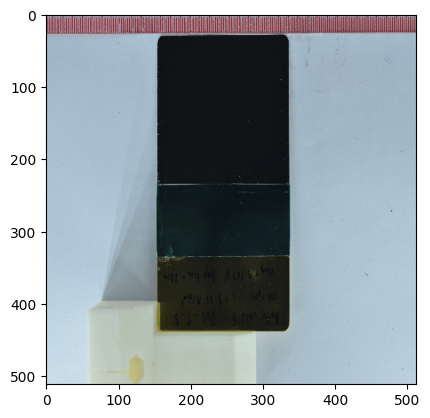

In [ ]:
bgr = cv2.imread('original_bg.jpg')
rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)

reimg_bgr = cv2.resize(bgr, (1024,1024),interpolation=None)
reimg_rgb = cv2.resize(rgb, (1100,720),interpolation=None)

plt.imshow(reimg_rgb)

In [160]:
mask_generator = SamAutomaticMaskGenerator(sam)
result = mask_generator.generate(reimg_rgb)


In [148]:
len(result)

21

In [149]:
result[0].keys()

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])

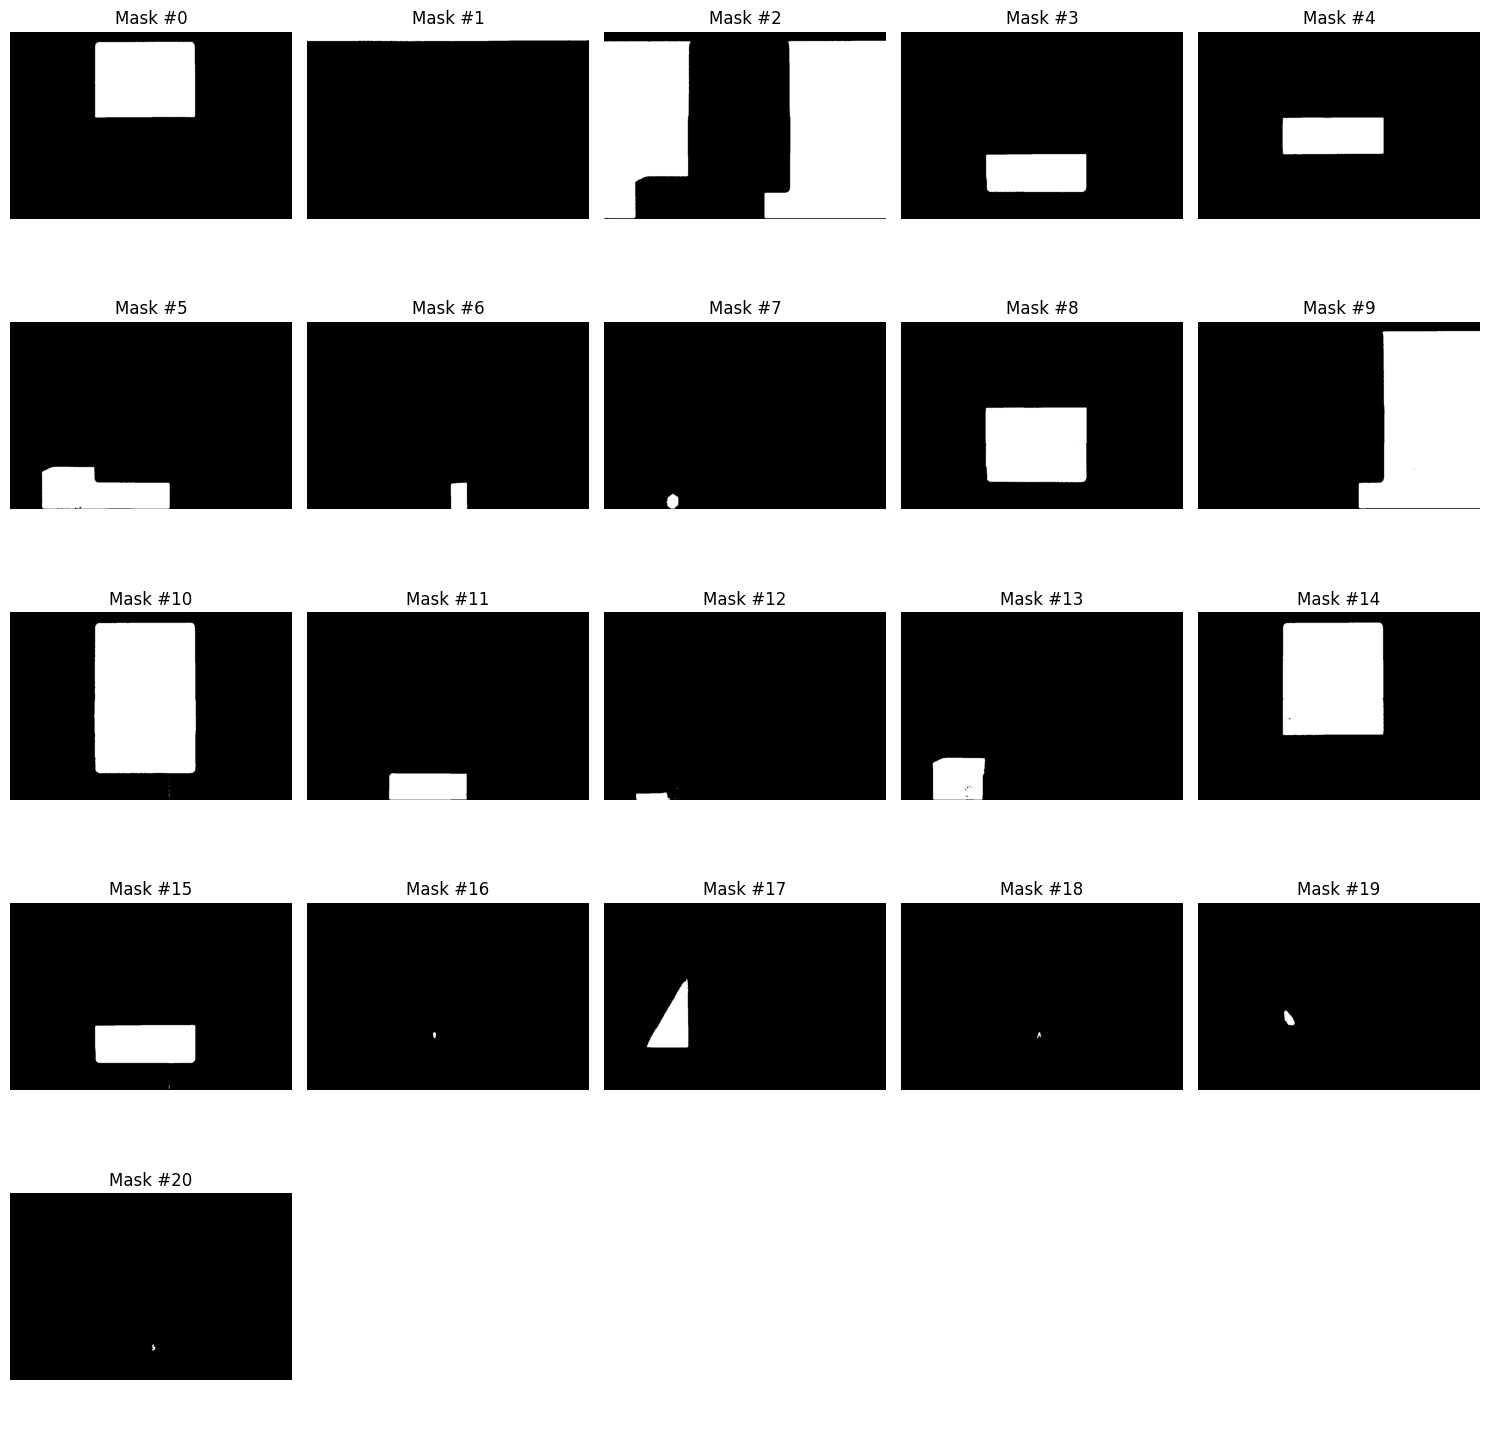

In [150]:
import matplotlib.pyplot as plt

# Number of masks
num_masks = len(result)

# Grid size (auto-calculate: square-ish)
cols = 5
rows = math.ceil(num_masks / cols)

# Create subplots
fig, axs = plt.subplots(rows, cols, figsize=(15, rows * 3))
axs = axs.flatten()

for i, mask in enumerate(result):
    binary_mask = mask['segmentation'].astype(np.uint8) * 255
    axs[i].imshow(binary_mask, cmap='gray')
    axs[i].set_title(f"Mask #{i}")
    axs[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


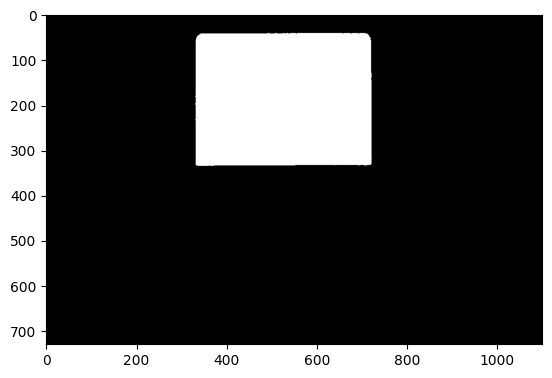

In [157]:
plt.imshow(result[0]['segmentation'].astype(np.uint8) * 255,cmap='gray')

## SamPredictor 

In [165]:
predictor = SamPredictor(sam)
predictor.set_image(reimg_bgr)  # ภาพที่ resize แล้ว

In [166]:
input_point = np.array([[512, 512]])  # (x, y) pixel location
input_label = np.array([1])  # 1 = foreground

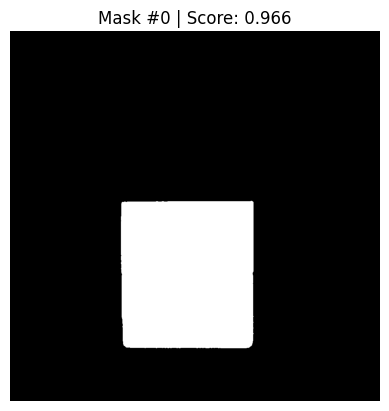

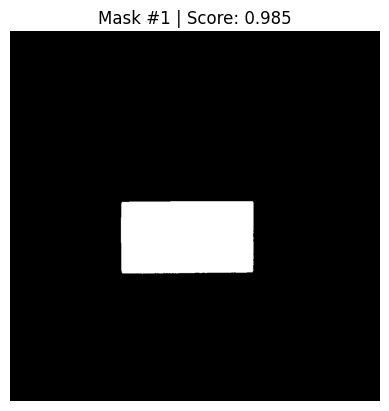

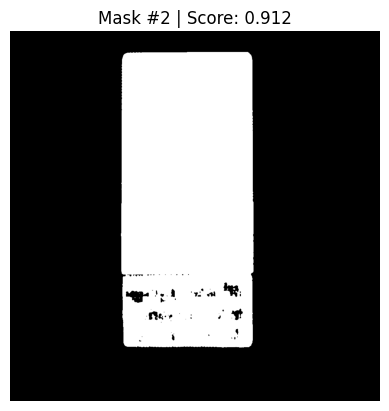

In [167]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True  # จะได้หลายทางเลือก
)

# แสดงผล
for i, mask in enumerate(masks):
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask #{i} | Score: {scores[i]:.3f}")
    plt.axis("off")
    plt.show()

In [ ]:
# ฟังก์ชันตอนคลิก
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        print(f"🖱 Click at ({x},{y})")

        input_point = np.array([[x, y]])
        input_label = np.array([1])

        masks, scores, _ = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=False
        )

        for i, mask in enumerate(masks):
            binary = mask.astype(np.uint8) * 255
            cv2.imshow(f"Mask {i}", binary)

# แสดงภาพให้คลิก
cv2.namedWindow("Click to segment")
cv2.setMouseCallback("Click to segment", click_event)

while True:
    cv2.imshow("Click to segment", cv2.cvtColor(reimg_rgb, cv2.COLOR_RGB2BGR))
    if cv2.waitKey(1) & 0xFF == ord('e'):  # กด Esc เพื่อออก
        break

cv2.destroyAllWindows()

🖱 Click at (695,604)
